# Electricity Price Forecasting — Results Summary

## Project Overview
Prediction of hourly electricity prices in the Spanish spot market (OMIE) 
using 6 years of historical data (2019–2024). The model is trained on 
2019–2023 and evaluated on 2024 as held-out test set.

In [1]:
import joblib
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import mean_absolute_error

base_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
db_path = os.path.join(base_dir, "data", "electricity.db")
models_dir = os.path.join(base_dir, "models")

# Cargar datos
conn = sqlite3.connect(db_path)
df = pd.read_sql("""
    SELECT * FROM omie_features_historic
    ORDER BY datetime
""", conn)
conn.close()

df["datetime"] = pd.to_datetime(df["datetime"])

# Cargar modelos
ridge = joblib.load(os.path.join(models_dir, "ridge.pkl"))
rf = joblib.load(os.path.join(models_dir, "random_forest.pkl"))
xgb = joblib.load(os.path.join(models_dir, "xgboost.pkl"))

# Recrear split
features = [
    "hour_sin", "hour_cos", "doy_sin", "doy_cos",
    "weekday_sin", "weekday_cos", "is_weekend",
    "post_excepcion", "lag_1", "lag_24", "lag_168",
    "rolling_mean_24", "rolling_mean_168"
]

split_date = "2024-01-01"
test_mask = df["datetime"] >= split_date

X_test = df[features][test_mask]
y_test = df["price_es"][test_mask]
datetime_test = df["datetime"][test_mask].reset_index(drop=True)

# Predicciones
xgb_pred = xgb.predict(X_test)
ridge_pred = ridge.predict(X_test)
rf_pred = rf.predict(X_test)
baseline_pred = X_test["lag_24"]

print("Modelos y datos cargados correctamente")

Modelos y datos cargados correctamente


## 1. Model Performance
Comparison of all models on the 2024 held-out test set.

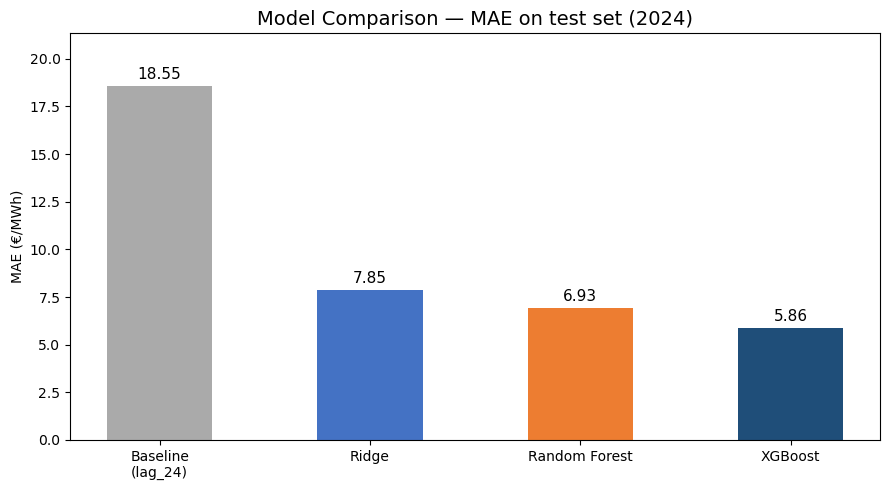

In [2]:
models = ["Baseline\n(lag_24)", "Ridge", "Random Forest", "XGBoost"]
maes = [
    mean_absolute_error(y_test, baseline_pred),
    mean_absolute_error(y_test, ridge_pred),
    mean_absolute_error(y_test, rf_pred),
    mean_absolute_error(y_test, xgb_pred)
]
colors = ["#AAAAAA", "#4472C4", "#ED7D31", "#1F4E79"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(models, maes, color=colors, width=0.5)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=11)
ax.set_title("Model Comparison — MAE on test set (2024)", fontsize=14)
ax.set_ylabel("MAE (€/MWh)")
ax.set_ylim(0, max(maes) * 1.15)
plt.tight_layout()
plt.show()

## 2. Predictions vs Reality
XGBoost predictions vs actual prices on the test set (2024).
January 2024 shown for clarity.

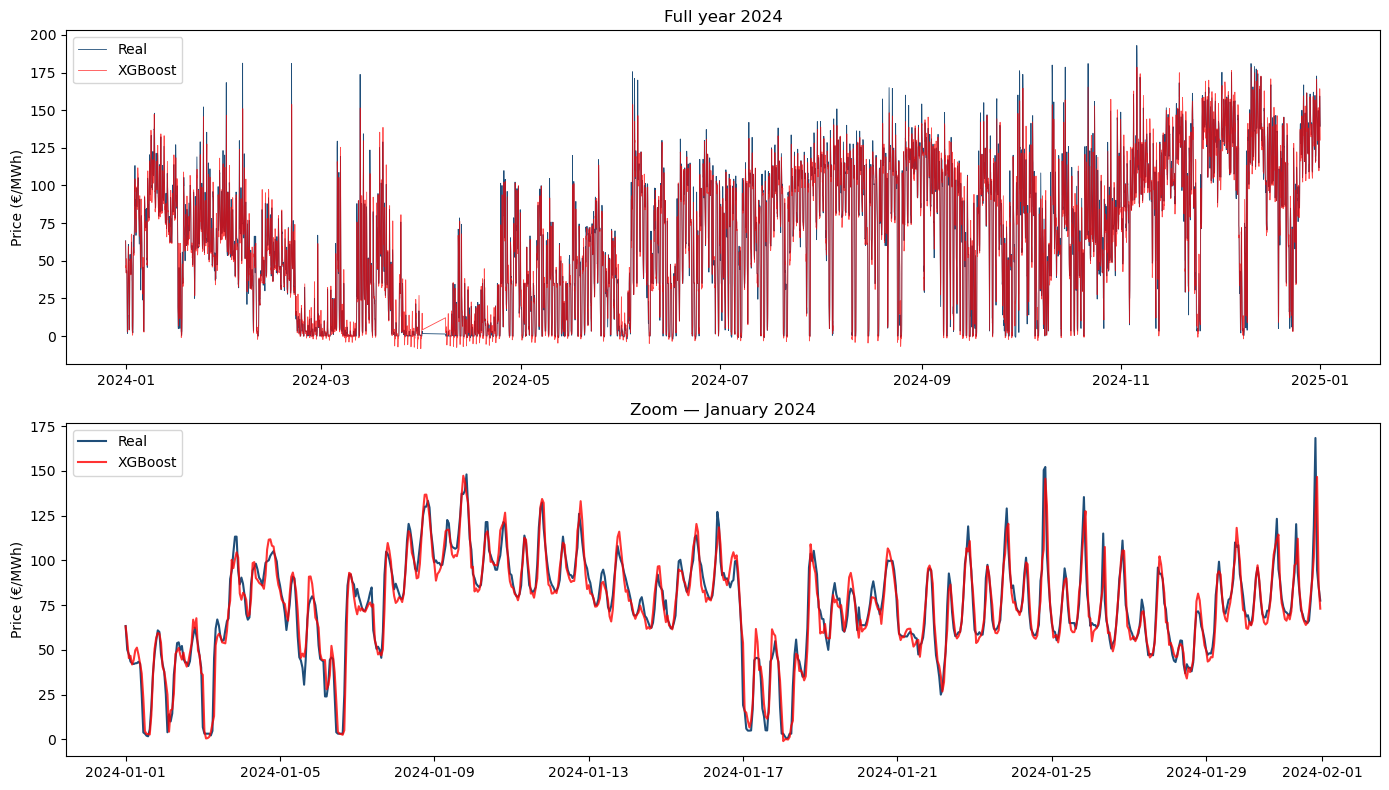

In [4]:
mask_enero = (datetime_test >= "2024-01-01") & (datetime_test < "2024-02-01")

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Plot 1 — año completo
axes[0].plot(datetime_test, y_test.reset_index(drop=True),
             label="Real", color="#1F4E79", linewidth=0.6)
axes[0].plot(datetime_test, xgb_pred,
             label=f"XGBoost", color="red", linewidth=0.6, alpha=0.7)
axes[0].set_title("Full year 2024", fontsize=12)
axes[0].set_ylabel("Price (€/MWh)")
axes[0].legend()

# Plot 2 — zoom enero
axes[1].plot(datetime_test[mask_enero], y_test.reset_index(drop=True)[mask_enero],
             label="Real", color="#1F4E79", linewidth=1.5)
axes[1].plot(datetime_test[mask_enero], xgb_pred[mask_enero],
             label="XGBoost", color="red", linewidth=1.5, alpha=0.8)
axes[1].set_title("Zoom — January 2024", fontsize=12)
axes[1].set_ylabel("Price (€/MWh)")
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/results_predictions.png", dpi=150)
plt.show()

## 3. Feature Importance
Which variables drive the XGBoost predictions most.

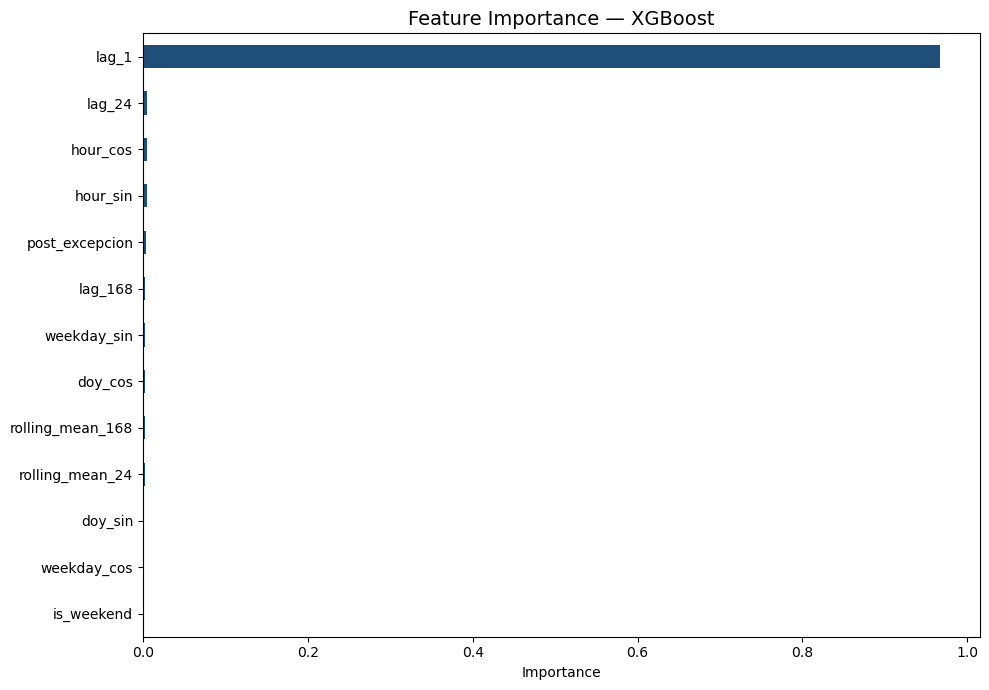

In [5]:
importance = pd.Series(xgb.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importance.plot(kind="barh", ax=ax, color="#1F4E79")
ax.set_title("Feature Importance — XGBoost", fontsize=14)
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("../outputs/results_feature_importance.png", dpi=150)
plt.show()

## 4. Market Regime Analysis
Two distinct market regimes identified: pre and post Iberian Exception (June 2022).

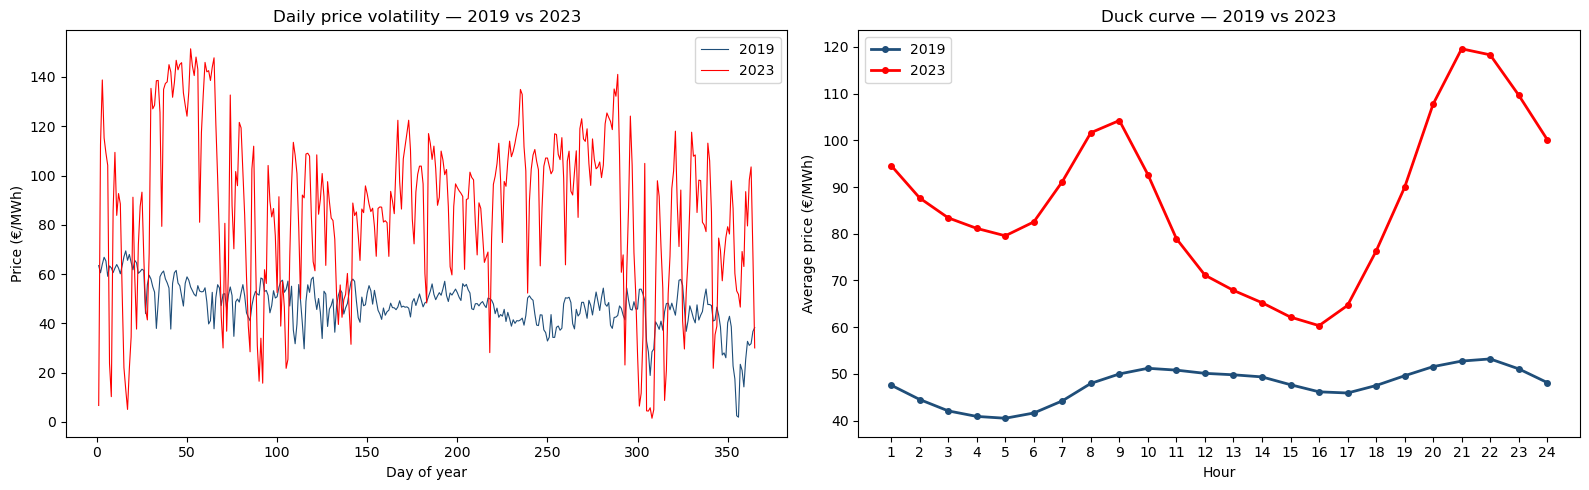

In [6]:
# Cargar datos sin features para el análisis de régimen
conn = sqlite3.connect(db_path)
df_raw = pd.read_sql("""
    SELECT year, month, day, AVG(price_es) as avg_price
    FROM omie_prices_historic
    WHERE hour BETWEEN 1 AND 24
    AND year IN (2019, 2023)
    GROUP BY year, month, day
    ORDER BY year, month, day
""", conn)
conn.close()

df_raw["date"] = pd.to_datetime(df_raw[["year", "month", "day"]])
df_2019 = df_raw[df_raw["year"] == 2019]
df_2023 = df_raw[df_raw["year"] == 2023]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — precio diario 2019 vs 2023
axes[0].plot(df_2019["date"].dt.dayofyear, df_2019["avg_price"],
             label="2019", color="#1F4E79", linewidth=0.8)
axes[0].plot(df_2023["date"].dt.dayofyear, df_2023["avg_price"],
             label="2023", color="red", linewidth=0.8)
axes[0].set_title("Daily price volatility — 2019 vs 2023", fontsize=12)
axes[0].set_xlabel("Day of year")
axes[0].set_ylabel("Price (€/MWh)")
axes[0].legend()

# Plot 2 — curva de pato 2019 vs 2023
conn = sqlite3.connect(db_path)
df_pato = pd.read_sql("""
    SELECT year, hour, AVG(price_es) as avg_price
    FROM omie_prices_historic
    WHERE hour BETWEEN 1 AND 24
    AND year IN (2019, 2023)
    GROUP BY year, hour
    ORDER BY year, hour
""", conn)
conn.close()

df_pato_2019 = df_pato[df_pato["year"] == 2019]
df_pato_2023 = df_pato[df_pato["year"] == 2023]

axes[1].plot(df_pato_2019["hour"], df_pato_2019["avg_price"],
             label="2019", color="#1F4E79", linewidth=2, marker="o", markersize=4)
axes[1].plot(df_pato_2023["hour"], df_pato_2023["avg_price"],
             label="2023", color="red", linewidth=2, marker="o", markersize=4)
axes[1].set_title("Duck curve — 2019 vs 2023", fontsize=12)
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Average price (€/MWh)")
axes[1].set_xticks(range(1, 25))
axes[1].legend()

plt.tight_layout()
plt.savefig("../outputs/results_market_regime.png", dpi=150)
plt.show()

## 5. Key Insights

- **XGBoost achieves MAE of 5.86 €/MWh** on 2024, ~9% relative error on mean price
- **lag_1 dominates predictions (0.97 importance)** — electricity prices have strong 
short-term autocorrelation
- **post_excepcion variable confirms two market regimes** — pre and post Iberian 
Exception of June 2022, with structurally higher volatility in the current regime
- **Duck curve emerged in 2023** — barely visible in 2019, clearly present in 2023, 
reflecting Spain's rapid solar capacity growth
- **Next steps:** incorporate ESIOS renewable generation data (solar, wind, hydro) 
to reduce lag_1 dependency and improve predictions on longer horizons